# Smart Expense & Financial Risk Analyzer

## Machine Learning and Data Science Analysis

This project analyzes personal financial transactions to understand spending behavior, detect unusual transactions, segment spending patterns, predict future expenses, and evaluate overall financial health.

### Objectives
- Analyze income and expenses
- Understand category-wise spending
- Identify spending trends
- Detect unusual transactions using Isolation Forest
- Segment spending behavior using K-Means clustering
- Predict future expenses using Linear Regression
- Calculate a Financial Health Score
- Identify financial risk levels
- Generate personalized financial recommendations

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Jupyter Notebook

### Machine Learning Techniques

1. Isolation Forest — Anomaly Detection
2. K-Means Clustering — Spending Segmentation
3. Linear Regression — Expense Prediction

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Load Dataset

The personal finance transaction dataset is loaded from the project's data folder.

In [7]:
file_path = "../data/Personal_Finance_Dataset.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [8]:
df.head()

,Date,Transaction Description,Category,Amount,Type
0,2020-01-02,Score each.,Food & Drink,1485.69,Expense
1,2020-01-02,Quality throughout.,Utilities,1475.58,Expense
2,2020-01-04,Instead ahead despite measure ago.,Rent,1185.08,Expense
3,2020-01-05,Information last everything thank serve.,Investment,2291.00,Income
4,2020-01-13,Future choice whatever from.,Food & Drink,1126.88,Expense


## 2. Dataset Overview

This section examines the structure, size, data types, statistical information, and overall quality of the dataset.

In [9]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

Number of rows: 1500
Number of columns: 5

Column names:
['Date', 'Transaction Description', 'Category', 'Amount', 'Type']


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Date                     1500 non-null   str    
 1   Transaction Description  1500 non-null   str    
 2   Category                 1500 non-null   str    
 3   Amount                   1500 non-null   float64
 4   Type                     1500 non-null   str    
dtypes: float64(1), str(4)
memory usage: 58.7 KB


In [11]:
df.describe(include="all")

,Date,Transaction Description,Category,Amount,Type
count,1500,1500,1500,1500.000000,1500
unique,1025,1500,10,NaN,2
top,2023-01-24,Score each.,Rent,NaN,Expense
freq,6,1,165,NaN,1222
mean,NaN,NaN,NaN,1307.520913,NaN
std,NaN,NaN,NaN,982.283361,NaN
min,NaN,NaN,NaN,14.370000,NaN
25%,NaN,NaN,NaN,629.340000,NaN
50%,NaN,NaN,NaN,1156.285000,NaN
75%,NaN,NaN,NaN,1712.932500,NaN


## 3. Missing Value Analysis

Missing values are checked to ensure that incomplete records do not affect the analysis or machine learning models.

In [12]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
Date                       0
Transaction Description    0
Category                   0
Amount                     0
Type                       0
dtype: int64


In [13]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

print("Missing value percentage:")
print(missing_percentage)

Missing value percentage:
Date                       0.0
Transaction Description    0.0
Category                   0.0
Amount                     0.0
Type                       0.0
dtype: float64


## 4. Duplicate Record Analysis

Duplicate transactions are identified and removed to prevent repeated records from affecting the analysis.

In [14]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate records:", duplicate_count)

Number of duplicate records: 0


In [15]:
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (1500, 5)


## 5. Data Cleaning and Preprocessing

The Date column is converted into datetime format and the Amount column is converted into numerical format.

This ensures that the dataset is suitable for financial analysis and machine learning.

In [16]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

df["Amount"] = pd.to_numeric(df["Amount"], errors="coerce")

print("Data types after conversion:")
print(df.dtypes)

Data types after conversion:
Date                       datetime64[us]
Transaction Description               str
Category                              str
Amount                            float64
Type                                  str
dtype: object


In [17]:
print("Missing dates:", df["Date"].isnull().sum())
print("Missing amounts:", df["Amount"].isnull().sum())

Missing dates: 0
Missing amounts: 0


In [18]:
df = df.dropna(subset=["Date", "Amount"])

print("Final dataset shape:", df.shape)

Final dataset shape: (1500, 5)


## 6. Feature Engineering

Additional time-based features are created from the transaction date.

These features help us analyze monthly and yearly spending patterns.

In [19]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.month_name()
df["Day"] = df["Date"].dt.day
df["Day_of_Week"] = df["Date"].dt.day_name()

df.head()

,Date,Transaction Description,Category,Amount,Type,Year,Month,Month_Name,Day,Day_of_Week
0,2020-01-02,Score each.,Food & Drink,1485.69,Expense,2020,1,January,2,Thursday
1,2020-01-02,Quality throughout.,Utilities,1475.58,Expense,2020,1,January,2,Thursday
2,2020-01-04,Instead ahead despite measure ago.,Rent,1185.08,Expense,2020,1,January,4,Saturday
3,2020-01-05,Information last everything thank serve.,Investment,2291.00,Income,2020,1,January,5,Sunday
4,2020-01-13,Future choice whatever from.,Food & Drink,1126.88,Expense,2020,1,January,13,Monday


## 7. Basic Financial Analysis

The dataset is separated into income and expense transactions to calculate total income, total expenses, and savings.

In [20]:
print("Transaction types:")
print(df["Type"].value_counts())

Transaction types:
Type
Expense    1222
Income      278
Name: count, dtype: int64


In [21]:
income_df = df[df["Type"].str.lower() == "income"].copy()

expense_df = df[df["Type"].str.lower() == "expense"].copy()

print("Income transactions:", len(income_df))
print("Expense transactions:", len(expense_df))

Income transactions: 278
Expense transactions: 1222


In [22]:
total_income = income_df["Amount"].sum()
total_expense = expense_df["Amount"].sum()
total_savings = total_income - total_expense

print("Total Income:", round(total_income, 2))
print("Total Expense:", round(total_expense, 2))
print("Total Savings:", round(total_savings, 2))

Total Income: 734087.0
Total Expense: 1227194.37
Total Savings: -493107.37


## 8. Income vs Expense Visualization

A comparison between total income and total expenses is created to understand the overall financial position.

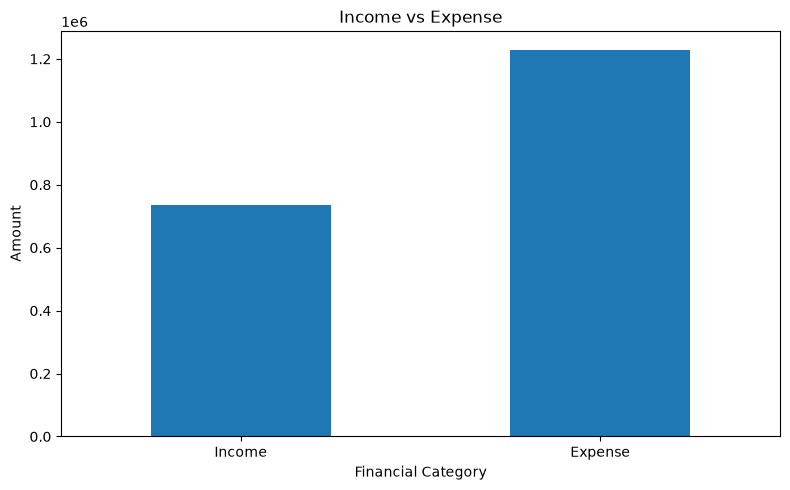

In [23]:
financial_summary = pd.Series({
    "Income": total_income,
    "Expense": total_expense
})

financial_summary.plot(kind="bar", figsize=(8, 5))

plt.title("Income vs Expense")
plt.ylabel("Amount")
plt.xlabel("Financial Category")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 9. Category-wise Expense Analysis

Expense transactions are grouped by category to identify the categories that consume the largest portion of the user's money.

In [24]:
category_expenses = (
    expense_df.groupby("Category")["Amount"]
    .sum()
    .sort_values(ascending=False)
)

category_expenses

Category
Travel              169497.79
Rent                162075.39
Food & Drink        159493.39
Salary              149053.55
Entertainment       148165.47
Shopping            146880.75
Utilities           146833.97
Health & Fitness    145194.06
Name: Amount, dtype: float64

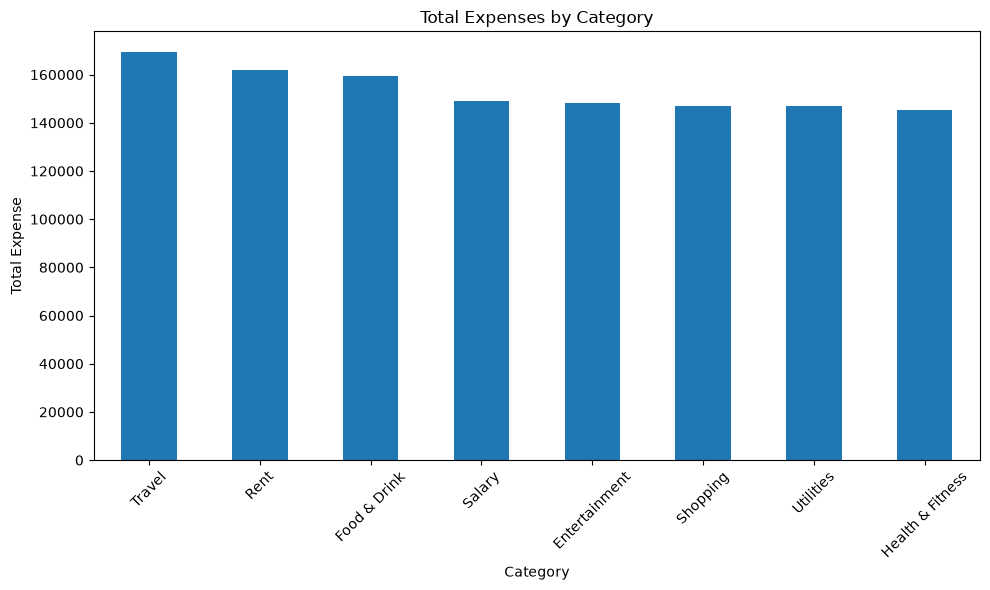

In [25]:
plt.figure(figsize=(10, 6))

category_expenses.plot(kind="bar")

plt.title("Total Expenses by Category")
plt.xlabel("Category")
plt.ylabel("Total Expense")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 10. Expense Distribution

The percentage contribution of each category to total expenses is calculated to identify major spending areas.

In [26]:
category_percentage = (
    category_expenses / category_expenses.sum()
) * 100

category_percentage

Category
Travel              13.811813
Rent                13.206986
Food & Drink        12.996587
Salary              12.145880
Entertainment       12.073513
Shopping            11.968825
Utilities           11.965013
Health & Fitness    11.831383
Name: Amount, dtype: float64

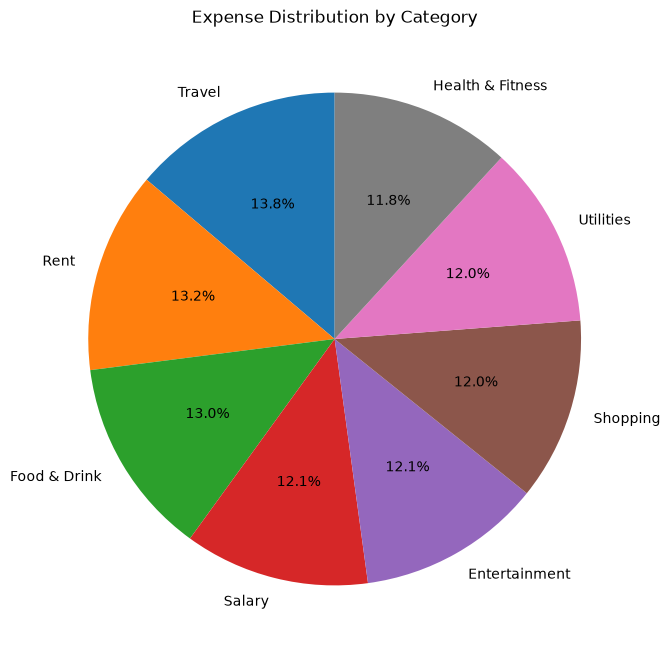

In [27]:
plt.figure(figsize=(8, 8))

plt.pie(
    category_percentage,
    labels=category_percentage.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Expense Distribution by Category")
plt.show()

## 11. Monthly Expense Analysis

Monthly expense totals are calculated to understand how spending changes over time.

In [28]:
monthly_expenses = (
    expense_df.groupby(["Year", "Month"])["Amount"]
    .sum()
    .reset_index()
)

monthly_expenses["Period"] = (
    monthly_expenses["Year"].astype(str)
    + "-"
    + monthly_expenses["Month"].astype(str).str.zfill(2)
)

monthly_expenses

,Year,Month,Amount,Period
0,2020,1,17138.25,2020-01
1,2020,2,17108.41,2020-02
2,2020,3,13581.81,2020-03
3,2020,4,16233.05,2020-04
4,2020,5,16846.13,2020-05
5,2020,6,20680.72,2020-06
6,2020,7,24026.27,2020-07
7,2020,8,31386.80,2020-08
8,2020,9,21515.15,2020-09
9,2020,10,22162.99,2020-10


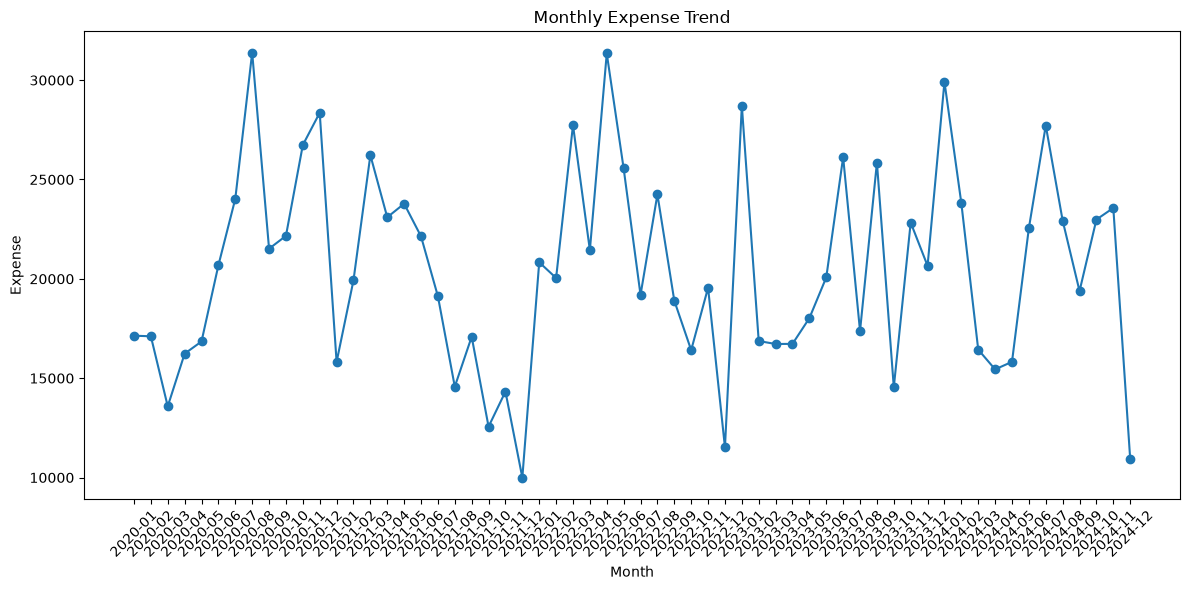

In [29]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_expenses["Period"],
    monthly_expenses["Amount"],
    marker="o"
)

plt.title("Monthly Expense Trend")
plt.xlabel("Month")
plt.ylabel("Expense")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 12. Income vs Expense Over Time

Monthly income and expenses are compared to understand whether financial behavior is improving or worsening over time.

In [30]:
monthly_income = (
    income_df.groupby(["Year", "Month"])["Amount"]
    .sum()
    .reset_index()
)

monthly_income["Period"] = (
    monthly_income["Year"].astype(str)
    + "-"
    + monthly_income["Month"].astype(str).str.zfill(2)
)

monthly_income

,Year,Month,Amount,Period
0,2020,1,5578.0,2020-01
1,2020,2,20070.0,2020-02
2,2020,3,3465.0,2020-03
3,2020,4,7370.0,2020-04
4,2020,5,6008.0,2020-05
5,2020,6,12346.0,2020-06
6,2020,7,6092.0,2020-07
7,2020,8,14941.0,2020-08
8,2020,9,1385.0,2020-09
9,2020,10,12897.0,2020-10


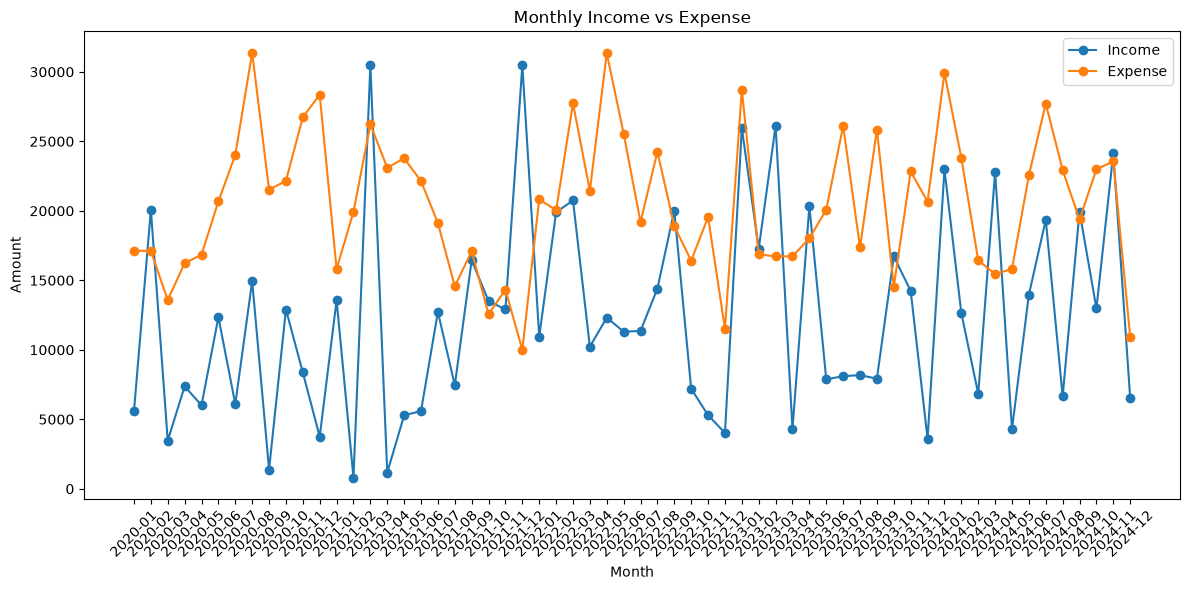

In [31]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_income["Period"],
    monthly_income["Amount"],
    marker="o",
    label="Income"
)

plt.plot(
    monthly_expenses["Period"],
    monthly_expenses["Amount"],
    marker="o",
    label="Expense"
)

plt.title("Monthly Income vs Expense")
plt.xlabel("Month")
plt.ylabel("Amount")
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

# 13. Anomaly Detection using Isolation Forest

Isolation Forest is an unsupervised machine learning algorithm used to identify unusual financial transactions.

Transactions with unusually high or low spending amounts can be flagged as potential anomalies.

These anomalies may represent unusual purchases, unexpected expenses, or transactions that deserve further review.

In [32]:
anomaly_model = IsolationForest(
    contamination=0.05,
    random_state=42
)

expense_df["Anomaly"] = anomaly_model.fit_predict(
    expense_df[["Amount"]]
)

print(expense_df["Anomaly"].value_counts())

Anomaly
 1    1160
-1      62
Name: count, dtype: int64


In [33]:
anomalies = expense_df[
    expense_df["Anomaly"] == -1
].copy()

print("Number of anomalous transactions:", len(anomalies))

anomalies[
    ["Date", "Transaction Description", "Category", "Amount"]
].sort_values(
    by="Amount",
    ascending=False
).head(10)

Number of anomalous transactions: 62


,Date,Transaction Description,Category,Amount
173,2020-08-22,Down occur.,Food & Drink,1999.82
243,2020-11-12,Order his oil west school.,Food & Drink,1999.15
354,2021-03-19,Across nothing.,Food & Drink,1997.19
586,2022-01-21,Enter example down anyone occur.,Health & Fitness,1996.26
287,2020-12-28,Song risk bad.,Travel,1994.88
1250,2024-02-24,Cup red collection husband.,Salary,1993.30
656,2022-04-05,Marriage participant.,Utilities,1985.77
1113,2023-09-16,Quite everyone as generation.,Utilities,1984.77
426,2021-06-06,Wait it quickly produce beat.,Salary,1982.06
720,2022-06-18,Day stock.,Entertainment,1980.56


## 14. Anomaly Visualization

The detected anomalous transactions are visualized to understand unusual spending behavior.

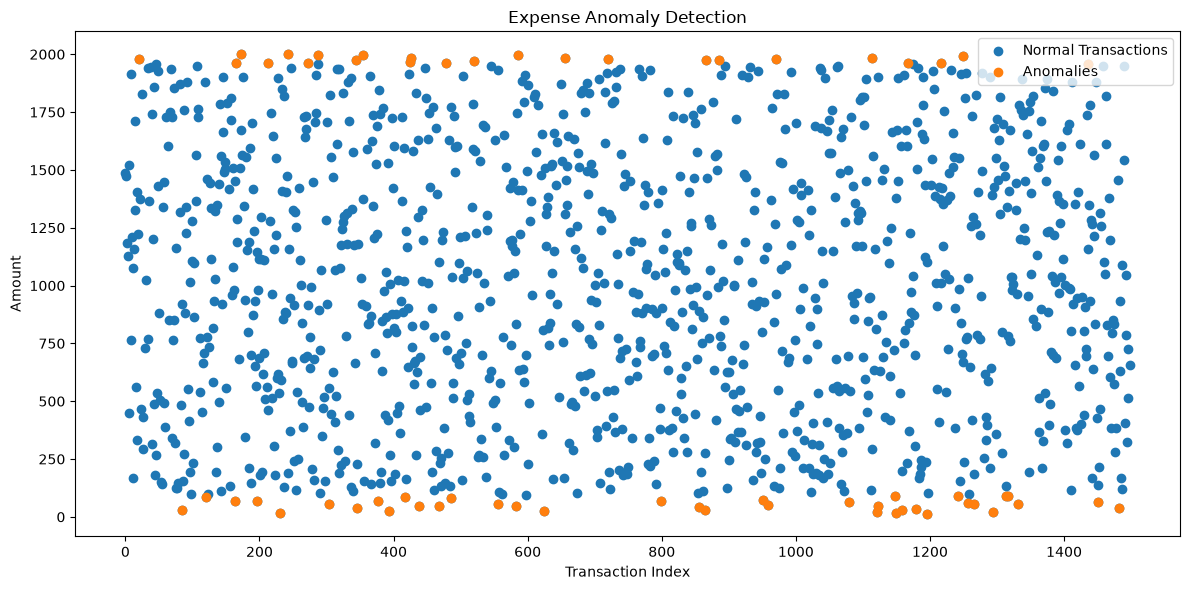

In [34]:
plt.figure(figsize=(12, 6))

plt.scatter(
    expense_df.index,
    expense_df["Amount"],
    label="Normal Transactions"
)

plt.scatter(
    anomalies.index,
    anomalies["Amount"],
    label="Anomalies"
)

plt.title("Expense Anomaly Detection")
plt.xlabel("Transaction Index")
plt.ylabel("Amount")
plt.legend()

plt.tight_layout()
plt.show()

# 15. Spending Behavior Segmentation using K-Means

K-Means clustering is used to group transactions according to their spending amounts.

The clusters help identify different levels of spending behavior such as:

- Lower spending
- Medium spending
- Higher spending

In [35]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

expense_df["Cluster"] = kmeans.fit_predict(
    expense_df[["Amount"]]
)

expense_df["Cluster"].value_counts()

Cluster
2    426
0    421
1    375
Name: count, dtype: int64

In [36]:
cluster_summary = (
    expense_df.groupby("Cluster")["Amount"]
    .agg(["count", "mean", "min", "max"])
)

cluster_summary

,count,mean,min,max
Cluster,,,,
0,421,959.633895,640.59,1301.99
1,375,320.628907,14.37,635.86
2,426,1650.123615,1305.75,1999.82


In [37]:
cluster_summary = cluster_summary.sort_values("mean")

cluster_summary

,count,mean,min,max
Cluster,,,,
1,375,320.628907,14.37,635.86
0,421,959.633895,640.59,1301.99
2,426,1650.123615,1305.75,1999.82


## 16. Cluster Interpretation

The clusters are interpreted according to their average transaction amount.

The cluster with the lowest average amount represents lower-value spending, while the cluster with the highest average amount represents higher-value spending.

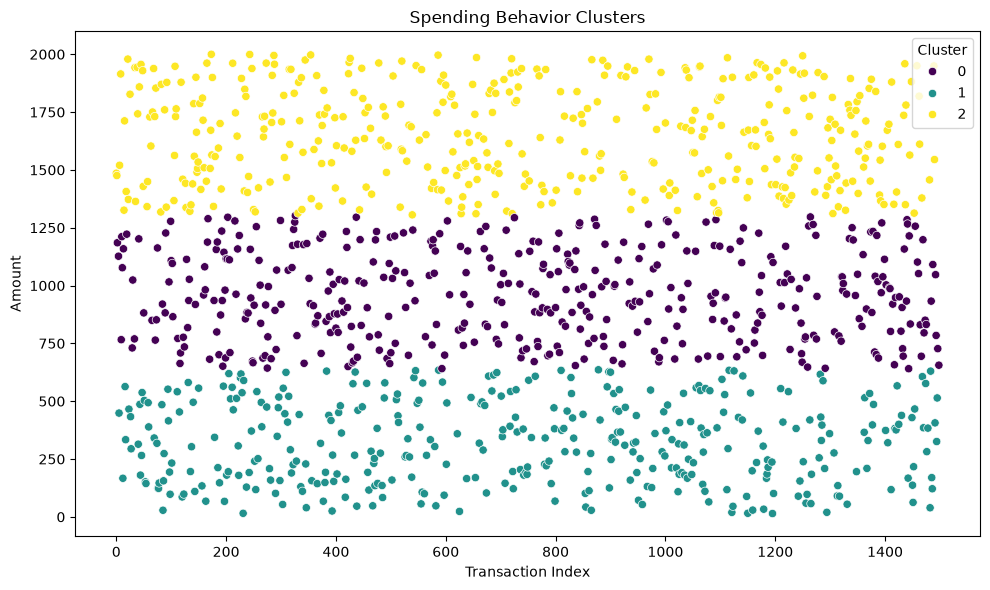

In [38]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=expense_df,
    x=expense_df.index,
    y="Amount",
    hue="Cluster",
    palette="viridis"
)

plt.title("Spending Behavior Clusters")
plt.xlabel("Transaction Index")
plt.ylabel("Amount")

plt.tight_layout()
plt.show()

# 17. Future Expense Prediction

Monthly expenses are used to build a Linear Regression model.

The model learns the overall trend in historical expenses and estimates the expense for the next available month.

In [39]:
monthly_expense = (
    expense_df.groupby(["Year", "Month"])["Amount"]
    .sum()
    .reset_index()
)

monthly_expense = monthly_expense.sort_values(
    ["Year", "Month"]
).reset_index(drop=True)

monthly_expense["Time_Index"] = range(
    len(monthly_expense)
)

monthly_expense

,Year,Month,Amount,Time_Index
0,2020,1,17138.25,0
1,2020,2,17108.41,1
2,2020,3,13581.81,2
3,2020,4,16233.05,3
4,2020,5,16846.13,4
5,2020,6,20680.72,5
6,2020,7,24026.27,6
7,2020,8,31386.80,7
8,2020,9,21515.15,8
9,2020,10,22162.99,9


## 18. Train Linear Regression Model

Linear Regression is trained using the time index as the independent variable and monthly expense as the target variable.

In [40]:
X = monthly_expense[["Time_Index"]]

y = monthly_expense["Amount"]

regression_model = LinearRegression()

regression_model.fit(X, y)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [41]:
monthly_expense["Predicted_Expense"] = (
    regression_model.predict(X)
)

monthly_expense

,Year,Month,Amount,Time_Index,Predicted_Expense
0,2020,1,17138.25,0,20336.625066
1,2020,2,17108.41,1,20340.578097
2,2020,3,13581.81,2,20344.531129
3,2020,4,16233.05,3,20348.484161
4,2020,5,16846.13,4,20352.437192
5,2020,6,20680.72,5,20356.390224
6,2020,7,24026.27,6,20360.343256
7,2020,8,31386.80,7,20364.296287
8,2020,9,21515.15,8,20368.249319
9,2020,10,22162.99,9,20372.202351


## 19. Actual vs Predicted Expenses

The actual monthly expenses are compared with the values predicted by the regression model.

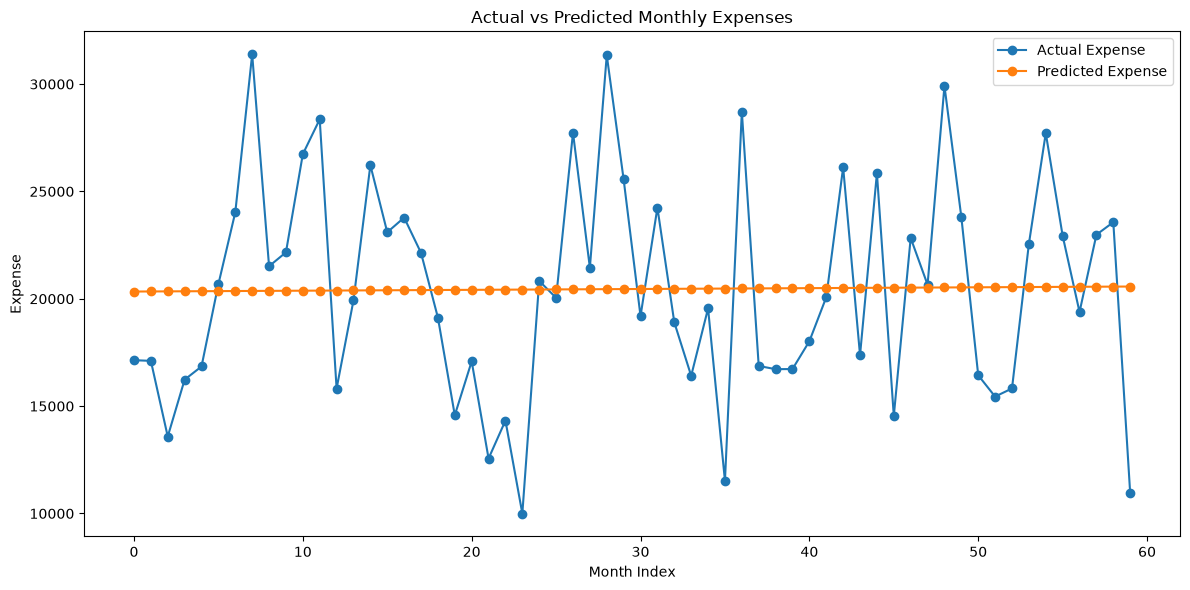

In [42]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_expense["Amount"],
    marker="o",
    label="Actual Expense"
)

plt.plot(
    monthly_expense["Predicted_Expense"],
    marker="o",
    label="Predicted Expense"
)

plt.title("Actual vs Predicted Monthly Expenses")
plt.xlabel("Month Index")
plt.ylabel("Expense")

plt.legend()
plt.tight_layout()
plt.show()

## 20. Model Evaluation

The regression model is evaluated using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

These metrics measure how closely the predicted expenses match the actual historical expenses.

In [43]:
y_pred = regression_model.predict(X)

mae = mean_absolute_error(y, y_pred)

rmse = np.sqrt(
    mean_squared_error(y, y_pred)
)

r2 = r2_score(y, y_pred)

print("Mean Absolute Error:", round(mae, 2))
print("Root Mean Squared Error:", round(rmse, 2))
print("R² Score:", round(r2, 4))

Mean Absolute Error: 4190.29
Root Mean Squared Error: 5076.88
R² Score: 0.0002


## 21. Next Month Expense Prediction

The trained regression model is used to estimate the expense for the next month.

In [44]:
next_month_index = np.array([
    [len(monthly_expense)]
])

next_month_prediction = regression_model.predict(
    next_month_index
)[0]

print(
    "Predicted expense for next month:",
    round(next_month_prediction, 2)
)

Predicted expense for next month: 20573.81


# 22. Financial Health Analysis

A Financial Health Score is calculated using important financial indicators:

- Savings rate
- Expense-to-income ratio
- Unusual transaction activity

The score provides a simple interpretation of the user's overall financial condition.

In [45]:
if total_income > 0:
    expense_ratio = (total_expense / total_income) * 100
    savings_rate = (total_savings / total_income) * 100
else:
    expense_ratio = 100
    savings_rate = 0

print("Expense-to-Income Ratio:", round(expense_ratio, 2), "%")
print("Savings Rate:", round(savings_rate, 2), "%")

Expense-to-Income Ratio: 167.17 %
Savings Rate: -67.17 %


## 23. Financial Health Score

The Financial Health Score is calculated on a scale of 0 to 100.

Higher scores indicate healthier financial behavior.

In [46]:
# Savings component
if savings_rate >= 30:
    savings_score = 40
elif savings_rate >= 20:
    savings_score = 30
elif savings_rate >= 10:
    savings_score = 20
elif savings_rate > 0:
    savings_score = 10
else:
    savings_score = 0


# Expense component
if expense_ratio <= 50:
    expense_score = 40
elif expense_ratio <= 70:
    expense_score = 30
elif expense_ratio <= 90:
    expense_score = 20
elif expense_ratio <= 100:
    expense_score = 10
else:
    expense_score = 0


# Anomaly component
anomaly_rate = (
    len(anomalies) / len(expense_df) * 100
    if len(expense_df) > 0 else 0
)

if anomaly_rate <= 2:
    anomaly_score = 20
elif anomaly_rate <= 5:
    anomaly_score = 15
elif anomaly_rate <= 10:
    anomaly_score = 10
elif anomaly_rate <= 20:
    anomaly_score = 5
else:
    anomaly_score = 0


financial_health_score = (
    savings_score +
    expense_score +
    anomaly_score
)

print("Financial Health Score:", financial_health_score, "/ 100")

Financial Health Score: 10 / 100


In [47]:
if financial_health_score >= 80:
    health_status = "Excellent"
elif financial_health_score >= 60:
    health_status = "Good"
elif financial_health_score >= 40:
    health_status = "Moderate"
else:
    health_status = "High Risk"

print("Financial Health Status:", health_status)

Financial Health Status: High Risk


# 24. Financial Risk Analysis

Financial risk is evaluated using:

1. Expense-to-income ratio
2. Savings rate
3. Number of unusual transactions
4. Overall financial health score

These indicators help identify whether the user's spending behavior may create financial pressure.

In [48]:
if expense_ratio > 100:
    risk_level = "High Risk"
elif expense_ratio > 80:
    risk_level = "Moderate Risk"
elif savings_rate < 10:
    risk_level = "Moderate Risk"
else:
    risk_level = "Low Risk"

print("Financial Risk Level:", risk_level)

Financial Risk Level: High Risk


# 25. Personalized Financial Recommendations

Based on the financial analysis, recommendations are generated to help improve spending and saving behavior.

In [49]:
recommendations = []

if savings_rate < 10:
    recommendations.append(
        "Try to increase your monthly savings by reducing unnecessary expenses."
    )

if expense_ratio > 80:
    recommendations.append(
        "Your expenses are high compared with your income. Consider reducing discretionary spending."
    )

if len(anomalies) > 0:
    recommendations.append(
        "Review unusual transactions detected by the anomaly detection model."
    )

if not category_expenses.empty:
    highest_category = category_expenses.index[0]

    recommendations.append(
        f"Monitor spending in the '{highest_category}' category because it is your highest expense category."
    )

if next_month_prediction > total_expense / max(len(monthly_expense), 1):
    recommendations.append(
        "The model indicates that future expenses may increase. Monitor your spending carefully."
    )

if len(recommendations) == 0:
    recommendations.append(
        "Your financial behavior appears stable. Continue monitoring expenses and maintaining savings."
    )

for i, recommendation in enumerate(recommendations, 1):
    print(f"{i}. {recommendation}")

1. Try to increase your monthly savings by reducing unnecessary expenses.
2. Your expenses are high compared with your income. Consider reducing discretionary spending.
3. Review unusual transactions detected by the anomaly detection model.
4. Monitor spending in the 'Travel' category because it is your highest expense category.
5. The model indicates that future expenses may increase. Monitor your spending carefully.


# 26. Final Project Results

The Smart Expense & Financial Risk Analyzer provides the following outputs:

- Total income
- Total expenses
- Total savings
- Category-wise spending
- Monthly expense trends
- Unusual transaction detection
- Spending behavior clusters
- Future expense prediction
- Model evaluation metrics
- Financial Health Score
- Financial Risk Level
- Personalized financial recommendations

In [50]:
print("=" * 50)
print("SMART EXPENSE & FINANCIAL RISK ANALYZER")
print("=" * 50)

print(f"Total Income       : {total_income:.2f}")
print(f"Total Expense      : {total_expense:.2f}")
print(f"Total Savings      : {total_savings:.2f}")

print(f"\nExpense Ratio      : {expense_ratio:.2f}%")
print(f"Savings Rate       : {savings_rate:.2f}%")

print(f"\nAnomalies Detected : {len(anomalies)}")
print(f"Health Score       : {financial_health_score}/100")
print(f"Health Status      : {health_status}")
print(f"Risk Level         : {risk_level}")

print(
    f"\nNext Month Expense Prediction: "
    f"{next_month_prediction:.2f}"
)

print("\nTop Expense Category:")
print(category_expenses.index[0])

print("\nRecommendations:")
for i, recommendation in enumerate(recommendations, 1):
    print(f"{i}. {recommendation}")

print("=" * 50)

SMART EXPENSE & FINANCIAL RISK ANALYZER
Total Income       : 734087.00
Total Expense      : 1227194.37
Total Savings      : -493107.37

Expense Ratio      : 167.17%
Savings Rate       : -67.17%

Anomalies Detected : 62
Health Score       : 10/100
Health Status      : High Risk
Risk Level         : High Risk

Next Month Expense Prediction: 20573.81

Top Expense Category:
Travel

Recommendations:
1. Try to increase your monthly savings by reducing unnecessary expenses.
2. Your expenses are high compared with your income. Consider reducing discretionary spending.
3. Review unusual transactions detected by the anomaly detection model.
4. Monitor spending in the 'Travel' category because it is your highest expense category.
5. The model indicates that future expenses may increase. Monitor your spending carefully.


# 27. Conclusion

The Smart Expense & Financial Risk Analyzer successfully combines data analysis and machine learning to analyze personal financial transactions.

The project performs exploratory data analysis to understand income and spending patterns, uses Isolation Forest to identify unusual transactions, applies K-Means clustering to identify different spending behaviors, and uses Linear Regression to predict future expenses.

A Financial Health Score and Financial Risk Level are also calculated using financial indicators such as savings rate, expense-to-income ratio, and anomalous transaction activity.

The resulting insights can be integrated into a Streamlit dashboard to provide users with an interactive financial analysis and decision-support application.

This project demonstrates practical skills in:

- Data Cleaning
- Exploratory Data Analysis
- Feature Engineering
- Data Visualization
- Anomaly Detection
- Unsupervised Machine Learning
- Clustering
- Regression
- Model Evaluation
- Financial Risk Analysis
- Recommendation Systems